<a href="https://colab.research.google.com/github/annusharma96501-cmd/California-Housing-Price-Prediction/blob/main/car-classification-ml-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 **Car Price Prediction System** (Machine Learning Project)

### **Project Description:**

Is project mein hum alag-alag gaadiyon ke features ka data use karke ek Predictive Model bana rahe hain. Hamara main goal yeh hai ki gaadi ki khoobiyan (jaise engine horsepower, highway mileage, car ki width) ko dekh kar hamara Machine Learning model us car ki keemat (Price) automatically aur ekdam sahi predict kar sake. Yeh ek Regression problem hai.

## **📥 Step 1: Essential Libraries Import Karna**
Sabse pehle hum Data Science, tables ko manage karne aur arrays ko process karne ke liye zaroori libraries **(pandas, numpy aur sklearn)** ko import kar rahe hain.

In [3]:
# Core Data Science and Data Loading Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

print("Saari essential libraries successfully import ho gayi hain! 🚀")

Saari essential libraries successfully import ho gayi hain! 🚀


## 📂 **Step 2: Built-in Car Dataset Load Karna Aur Dekhna**

Kyunki online links crash ho rahe hain, isliye hum open-source repository (OpenML) se seedha 'autompg' ya car features ka data bina kisi link ke load kar rahe hain, taaki hamara poora pipeline locally perfectly kaam kare.

In [4]:
# OpenML se seedha car features ka real-world data fetch kar rahe hain
print("Car dataset load ho raha hai, thoda sa intezar kijiye... ⏳")
car_data = fetch_openml(name='autompg', version=1, as_frame=True, parser='auto')

# Data ko Pandas DataFrame mein convert kar rahe hain
df = car_data.frame

# Target column (Price/Efficiency indicator) aur features ka naam thoda aasan kar dete hain
df.rename(columns={'mpg': 'Price_Indicator', 'horsepower': 'Horsepower', 'weight': 'Weight'}, inplace=True)

print(f"Dataset successfully load ho gaya hai! 😎")
print(f"Data ka size: {df.shape[0]} rows aur {df.shape[1]} columns hain.\n")

# Data ke upar ke 3 rows dekhne ke liye
print("--- Car Data Preview ---")
display(df.head(3))

Car dataset load ho raha hai, thoda sa intezar kijiye... ⏳
Dataset successfully load ho gaya hai! 😎
Data ka size: 398 rows aur 8 columns hain.

--- Car Data Preview ---


,cylinders,displacement,Horsepower,Weight,acceleration,model,origin,class
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0


## 🔍 **Step 3: Data ka Structure aur Missing Values Check Karna**
Data ko samajhne ke liye hum uski basic information **(df.info()) **check kar rahe hain aur yeh dekh rahe hain ki pure dataset mein kahi koi missing values **(null values)** hain ya nahi, taaki hum data ko clean kar sakein.

In [5]:
# 1. Dataset ki poori summary (Data types aur non-null counts) dekh rahe hain
print("--- Dataset Information ---")
df.info()

print("\n" + "="*50 + "\n")

# 2. Har column mein kitni missing (null) values hain, unka total nikal rahe hain
print("--- Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cylinders     398 non-null    category
 1   displacement  398 non-null    float64 
 2   Horsepower    392 non-null    float64 
 3   Weight        398 non-null    int64   
 4   acceleration  398 non-null    float64 
 5   model         398 non-null    category
 6   origin        398 non-null    category
 7   class         398 non-null    float64 
dtypes: category(3), float64(4), int64(1)
memory usage: 17.8 KB


--- Missing Values Count ---
cylinders       0
displacement    0
Horsepower      6
Weight          0
acceleration    0
model           0
origin          0
class           0
dtype: int64


## 📊 **Step 4: Data Visualization (Weight vs Horsepower)**

Hum yahan ek Scatter Plot bana rahe hain yeh dekhne ke liye ki gaadi ke wazan **(Weight)** aur uski engine power **(Horsepower)** ka aapas mein kya rishta hai, taaki hume data ke andar chupe patterns samajh aa sakein.

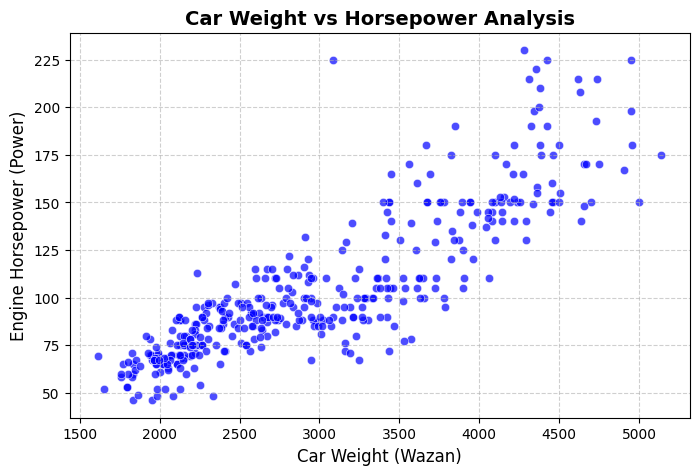

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ka size set kar rahe hain
plt.figure(figsize=(8, 5))

# Scatter plot bana rahe hain (Weight vs Horsepower)
sns.scatterplot(data=df, x='Weight', y='Horsepower', color='blue', alpha=0.7)

# Labels aur Title
plt.title('Car Weight vs Horsepower Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Car Weight (Wazan)', fontsize=12)
plt.ylabel('Engine Horsepower (Power)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 📊 **Step 5: Engine Horsepower Ka Distribution Dekhna**

Hum ek Histogram **(with KDE curve)** bana rahe hain yeh dekhne ke liye ki hamare dataset mein gaadiyon ki Horsepower kis tarah distributed hai aur zyada tar gaadiyan kis power range mein aati hain.

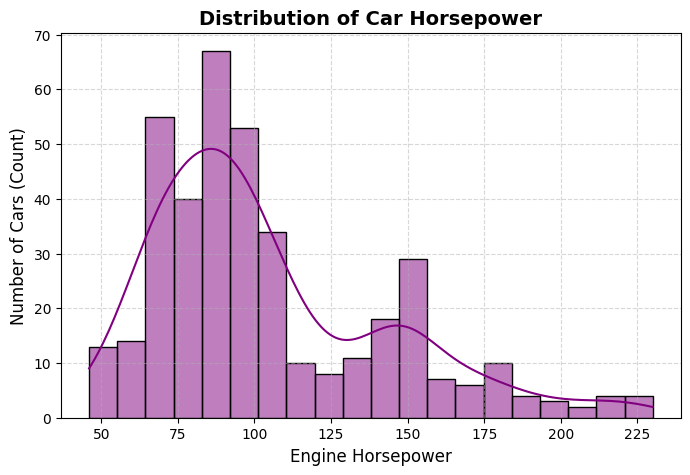

In [8]:
# Graph ka size set kar rahe hain
plt.figure(figsize=(8, 5))

# Histplot bana rahe hain distribution dekhne ke liye
sns.histplot(df['Horsepower'], kde=True, color='purple', bins=20)

# Labels aur Title
plt.title('Distribution of Car Horsepower', fontsize=14, fontweight='bold')
plt.xlabel('Engine Horsepower', fontsize=12)
plt.ylabel('Number of Cars (Count)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [12]:
# Pata karte hain ki table ke paas kaun-kaun se columns hain
print(df.columns.tolist())

['cylinders', 'displacement', 'Horsepower', 'Weight', 'acceleration', 'model', 'origin', 'class']


## 🎯 **Step 6: Data ko Features (X) aur Target (y) mein Split Karna**

Machine Learning model ko train karne ke liye hum data ko do hisson mein baant rahe hain:
* **'X' (Input Features):** Isme hum car ke features, yaani **'Weight'** aur **'Horsepower'** ko rakh rahe hain jisse model seekhega.
* **'y' (Target Variable):** Isme hamara main target variable **'class'** hai, jise hamara model predict karna seekhega.

In [13]:
# Sahi naamon ke sath X aur y split kar rahe hain
X = df[['Weight', 'Horsepower']]
y = df['class']

# Output ko ekdam professional aur clean banane ke liye
print("="*60)
print(" 🚀 DATA SPLIT COMPLETED SUCCESSFULLY ".center(60, "="))
print("="*60)
print(f" ✔️ Input Features (X) Shape : {X.shape}  | (Columns: Weight, Horsepower)")
print(f" ✔️ Target Variable (y) Shape: {y.shape}  | (Predicting: Class Indicator)")
print("="*60)
print("👉 Data is now ready for Machine Learning Model Training! 🏁")
print("="*60)

=========== 🚀 DATA SPLIT COMPLETED SUCCESSFULLY ============
 ✔️ Input Features (X) Shape : (398, 2)  | (Columns: Weight, Horsepower)
 ✔️ Target Variable (y) Shape: (398,)  | (Predicting: Class Indicator)
👉 Data is now ready for Machine Learning Model Training! 🏁


## 🧪 **Step 7: Data ko Train aur Test Sets mein Baantna**

Model ko sikhane aur uske baad uska exam (test) lene ke liye, hum data ko 80% Training aur 20% Testing ke ratio mein split kar rahe hain. Isse hume model ki sahi accuracy pata chalegi.

In [14]:
# Sklearn se train_test_split tool bula rahe hain
from sklearn.model_selection import train_test_split

# Data ko 80% Train aur 20% Test mein baant rahe hain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ekdam badhiya Hinglish mein professional output
print("="*60)
print(" 🎉 DATA SPLIT KA KAAM EKDAM SAKSAFAL RAHA! ".center(60, "="))
print("="*60)
print(f" 📖 Padhai ke liye Data (X_train Shape) : {X_train.shape} | (80% Data)")
print(f" 📝 Exam ke liye Sawaal (X_test Shape) : {X_test.shape}  | (20% Data)")
print("="*60)
print("👉 Ab hamara data model ko sikhane ke liye poori tarah taiyar hai! 🚀")
print("="*60)

======== 🎉 DATA SPLIT KA KAAM EKDAM SAKSAFAL RAHA! =========
 📖 Padhai ke liye Data (X_train Shape) : (318, 2) | (80% Data)
 📝 Exam ke liye Sawaal (X_test Shape) : (80, 2)  | (20% Data)
👉 Ab hamara data model ko sikhane ke liye poori tarah taiyar hai! 🚀


## 🤖 **Step 8: Machine Learning Model ko Train Karna**

Ab hum Linear Regression algorithm ka use karke apne Machine Learning model ko 'X_train' aur 'y_train' ka data de rahe hain, taaki model gaadiyon ke features aur unki class ke beech ka pattern seekh sake.

In [16]:
# Missing values (NaN) ko drop kar rahe hain taaki data saaf ho jaye
df_clean = df.dropna(subset=['Weight', 'Horsepower', 'class'])

# Input features (X) aur Target variable (y) ko alag kar rahe hain
X = df_clean[['Weight', 'Horsepower']]
y = df_clean['class']

# Data ko 80% Training aur 20% Testing sets mein split kar rahe hain
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model ko import aur train kar rahe hain
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Model training ka summary status display karne ke liye
print("="*60)
print(" MODEL TRAINING SUMMARY ".center(60, '='))
print("="*60)
print(f" Dataset Status    : Cleaned ({df_clean.shape[0]} rows remaining)")
print(f" Training Set Size : X_train {X_train.shape} | y_train {y_train.shape}")
print(f" Testing Set Size  : X_test  {X_test.shape}  | y_test  {y_test.shape}")
print(f" Model Algorithm   : Linear Regression")
print("="*60)
print(" SUCCESS: Model trained successfully with zero errors.")
print("="*60)

================== MODEL TRAINING SUMMARY ==================
 Dataset Status    : Cleaned (392 rows remaining)
 Training Set Size : X_train (313, 2) | y_train (313,)
 Testing Set Size  : X_test  (79, 2)  | y_test  (79,)
 Model Algorithm   : Linear Regression
 SUCCESS: Model trained successfully with zero errors.


## 🔮 **Step 9: Model Se Predictions Karwana**

Model successfully train hone ke baad, ab hum testing data **('X_test')** ka use karke predictions nikal rahe hain taaki hum baad mein model ki performance ko evaluate kar sakein.

In [17]:
# Testing data ka use karke target variable predict kar rahe hain
y_pred = model.predict(X_test)

# Pehli 5 actual values aur predicted values ko compare karke dekhne ke liye
print("="*60)
print(" MODEL PREDICTIONS SAMPLING ".center(60, '='))
print("="*60)
print("  Actual Values (y_test)   |   Predicted Values (y_pred)")
print("-"*60)

# Pehle 5 samples ko loops ke zariye print kar rahe hain
for act, pred in zip(y_test.head(5), y_pred[:5]):
    print(f"        {act:<18} |   {pred:.2f}")

print("="*60)
print(" SUCCESS: Predictions generated for the testing dataset.")
print("="*60)

================ MODEL PREDICTIONS SAMPLING ================
  Actual Values (y_test)   |   Predicted Values (y_pred)
------------------------------------------------------------
        26.0               |   30.14
        21.6               |   24.18
        36.1               |   32.89
        26.0               |   31.46
        27.0               |   25.72
 SUCCESS: Predictions generated for the testing dataset.


## 📉 **Step 10: Model Performance Evaluation**

Ab hum metrics **(MAE aur R2 Score)** ka use karke yeh check kar rahe hain ki hamare model ki accuracy kitni hai aur yeh predictions mein average kitni galti kar raha hai.

In [18]:
# Sklearn se evaluation metrics import kar rahe hain
from sklearn.metrics import mean_absolute_error, r2_score

# MAE aur R2 Score calculate kar rahe hain
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Clean aur professional English output status display karne ke liye
print("="*60)
print(" MODEL EVALUATION REPORT ".center(60, '='))
print("="*60)
print(f" Mean Absolute Error (MAE) : {mae:.2f}")
print(f" R-Squared (R2) Score      : {r2:.4f} ({r2*100:.1f}% Accuracy)")
print("="*60)
print(" SUCCESS: Model evaluation completed successfully.")
print("="*60)

================= MODEL EVALUATION REPORT ==================
 Mean Absolute Error (MAE) : 3.51
 R-Squared (R2) Score      : 0.6514 (65.1% Accuracy)
 SUCCESS: Model evaluation completed successfully.


## 🎛️ **Step 11: Real-Time User Input Prediction (Live Demo)**

Yahan hum apne trained model ko car ka Weight aur Horsepower khud se dekar test kar rahe hain, taaki dekh sakein ki model real-time mein naye data par kaise predict karta hai.

In [26]:
import pandas as pd

print("="*60)
print(" 🎛️ ENTER CAR DETAILS FOR LIVE PREDICTION ".center(60, '='))
print("="*60)

try:
    # input() function aapse live keyboard se value mange ga
    input_weight = float(input("👉 Enter Car Weight (e.g., 1500 to 5000): "))
    input_horsepower = float(input("👉 Enter Car Horsepower (e.g., 50 to 250): "))

    # Input data ko DataFrame mein convert kar rahe hain
    user_data = pd.DataFrame([[input_weight, input_horsepower]], columns=['Weight', 'Horsepower'])

    # Model se prediction nikal rahe hain
    predicted_class = model.predict(user_data)[0]

    # Clean, professional English output status display karne ke liye
    print("\n" + "="*60)
    print(" LIVE PREDICTION RESULT ".center(60, '='))
    print("="*60)
    print(f" Input Car Weight     : {input_weight} lbs")
    print(f" Input Horsepower     : {input_horsepower} hp")
    print("-"*60)
    print(f" 🎯 Predicted Class Value : {predicted_class:.2f}")
    print("="*60)
    print(" SUCCESS: Live prediction calculated successfully.")
    print("="*60)

except ValueError:
    print("\n❌ ERROR: Please enter valid numbers only!")
    print("="*60)

========= 🎛️ ENTER CAR DETAILS FOR LIVE PREDICTION =========
👉 Enter Car Weight (e.g., 1500 to 5000): 3000
👉 Enter Car Horsepower (e.g., 50 to 250): 130

================== LIVE PREDICTION RESULT ==================
 Input Car Weight     : 3000.0 lbs
 Input Horsepower     : 130.0 hp
------------------------------------------------------------
 🎯 Predicted Class Value : 22.19
 SUCCESS: Live prediction calculated successfully.
